## EDA

Explorations comparing the crime occurrence (OCC) timestamps to when incidents were reported.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8')
sns.set_palette('colorblind')

In [2]:
from ydata_profiling import ProfileReport ## use for quick EDA report --- IGNORE ---

In [3]:
data_path = 'Major_Crime_Indicators.csv'
date_cols = ['REPORT_DATE', 'OCC_DATE']

# Parse key timestamps and drop rows missing those anchors
df = pd.read_csv(data_path, parse_dates=date_cols)
df = df.dropna(subset=date_cols).copy()

# Calculate lag between when the crime occurred and when it was reported
seconds_per_day = 24 * 60 * 60
df['report_lag_days'] = (df['REPORT_DATE'] - df['OCC_DATE']).dt.total_seconds() / seconds_per_day

print(f'Loaded {len(df):,} rows with parsed timestamps.')
df[['REPORT_DATE', 'OCC_DATE', 'report_lag_days']].head()

Loaded 452,949 rows with parsed timestamps.


,REPORT_DATE,OCC_DATE,report_lag_days
0,2014-01-01 05:00:00,2014-01-01 05:00:00,0.0
1,2014-01-01 05:00:00,2014-01-01 05:00:00,0.0
2,2014-01-01 05:00:00,2014-01-01 05:00:00,0.0
3,2014-01-01 05:00:00,2014-01-01 05:00:00,0.0
4,2014-01-01 05:00:00,2014-01-01 05:00:00,0.0


### Monthly volume
Compare monthly counts using OCC and REPORT timestamps.

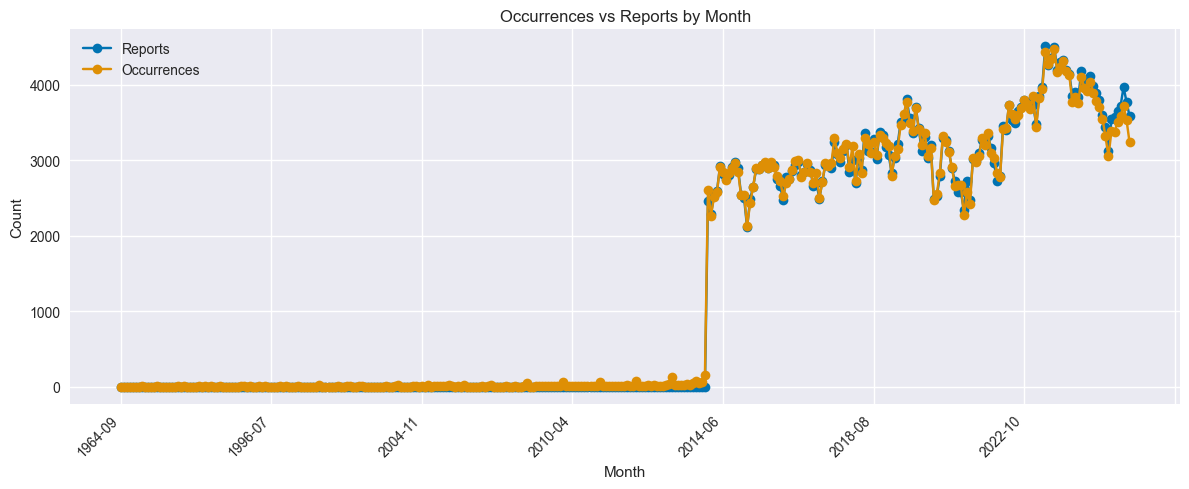

,Reports,Occurrences
2025-05,3646.0,3503
2025-06,3715.0,3580
2025-07,3965.0,3718
2025-08,3774.0,3529
2025-09,3581.0,3235


In [4]:
monthly_reports = df['REPORT_DATE'].dt.to_period('M').value_counts().sort_index()
monthly_occ = df['OCC_DATE'].dt.to_period('M').value_counts().sort_index()

monthly = pd.concat(
    [monthly_reports.rename('Reports'), monthly_occ.rename('Occurrences')],
    axis=1,
).fillna(0).sort_index()
monthly.index = monthly.index.astype(str)

ax = monthly.plot(figsize=(12, 5), marker='o')
ax.set_title('Occurrences vs Reports by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

monthly.tail()

### Day of week
Side-by-side bars to see if reports are clustered on different days than occurrences.

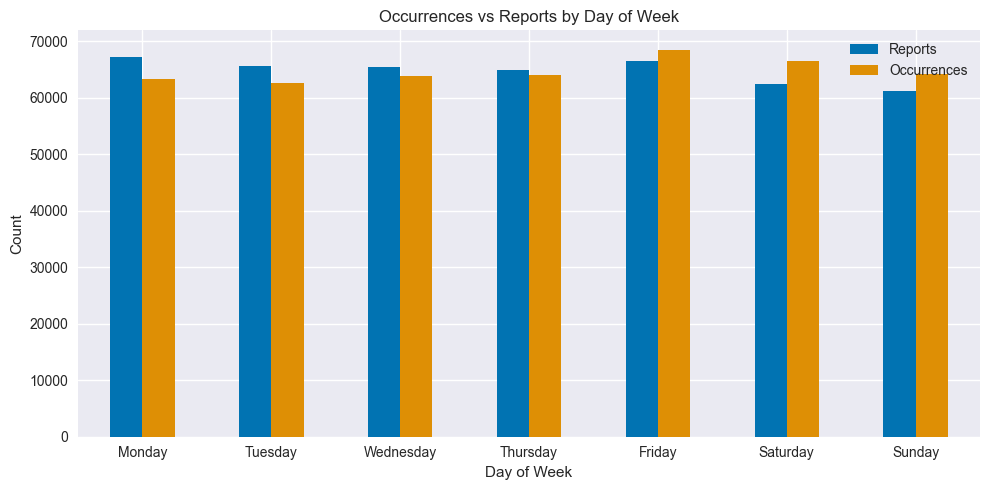

,Reports,Occurrences
Monday,67113,63369
Tuesday,65620,62631
Wednesday,65450,63870
Thursday,64817,64050
Friday,66475,68455
Saturday,62324,66410
Sunday,61150,64164


In [5]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = pd.DataFrame({
    'Reports': df['REPORT_DATE'].dt.day_name().value_counts(),
    'Occurrences': df['OCC_DATE'].dt.day_name().value_counts(),
}).reindex(weekday_order)

ax = dow.plot(kind='bar', figsize=(10, 5))
ax.set_title('Occurrences vs Reports by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dow

### Hour of day
Are reports logged at different times than incidents occur?

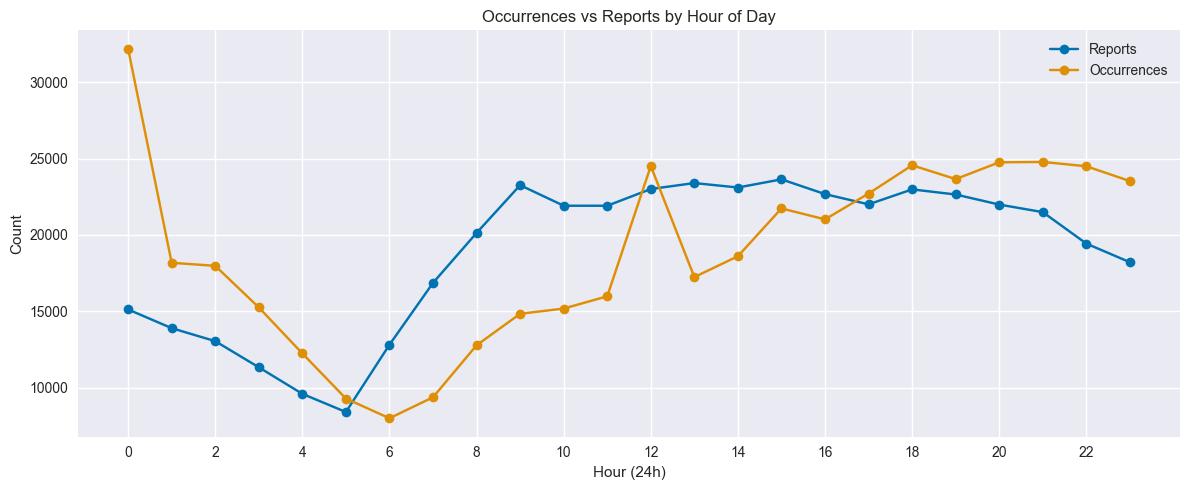

,Reports,Occurrences
0,15123,32188
1,13899,18179
2,13048,17980
3,11337,15258
4,9597,12245
5,8407,9288
6,12814,7999
7,16864,9374
8,20135,12778
9,23263,14841


In [6]:
hours = pd.DataFrame({
    'Reports': df['REPORT_HOUR'].value_counts().reindex(range(24), fill_value=0),
    'Occurrences': df['OCC_HOUR'].value_counts().reindex(range(24), fill_value=0),
})

ax = hours.plot(kind='line', figsize=(12, 5), marker='o')
ax.set_title('Occurrences vs Reports by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Count')
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

hours

### Report lag (days)
Distribution of the time between occurrence and report.

In [7]:
lag = df['report_lag_days']
lag.describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    452949.000000
mean         29.128972
std         309.493606
min           0.000000
50%           0.000000
90%           6.000000
95%          33.000000
99%         610.041667
max       22184.000000
Name: report_lag_days, dtype: float64

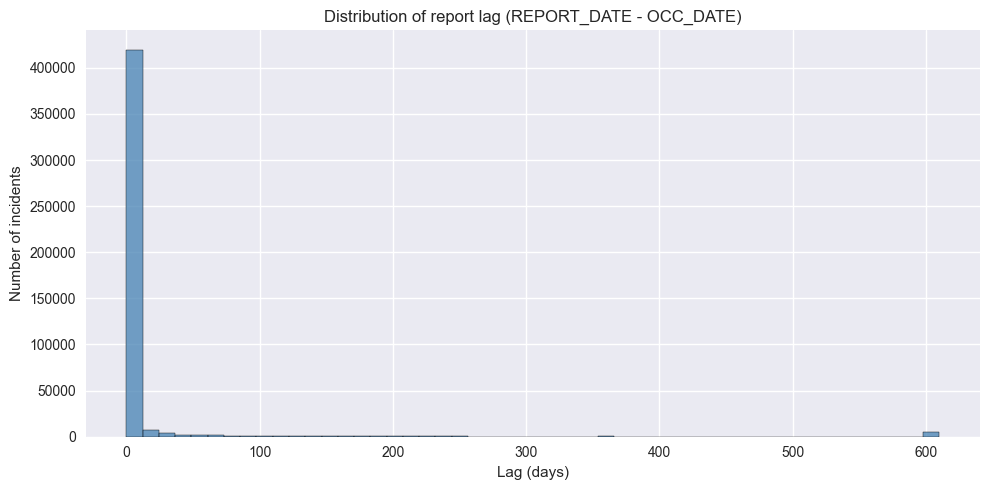

In [8]:
cutoff = lag.quantile(0.99)

plt.figure(figsize=(10, 5))
sns.histplot(lag.clip(upper=cutoff), bins=50, color='steelblue')
plt.title('Distribution of report lag (REPORT_DATE - OCC_DATE)')
plt.xlabel('Lag (days)')
plt.ylabel('Number of incidents')
plt.tight_layout()
plt.show()